In [32]:
from IPython.display import display, HTML
display(HTML('<style>pre { white-space: pre !important; }</style>'))

In [33]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Read JSON").getOrCreate()

transactions_df = spark.read.json("messages.json")

transactions_df.show()


+-------+-----------------+---------------+-----------+-------------+--------------------+---------------+--------------------+-----------------+-----------+--------------+----------+--------+--------------------+------------+--------------------+----------+
| amount|commission_amount|commission_type|customer_id|customer_type|         device_info| failure_reason|            location|merchant_category|merchant_id|payment_method|risk_level|  status|           timestamp|total_amount|      transaction_id|vat_amount|
+-------+-----------------+---------------+-----------+-------------+--------------------+---------------+--------------------+-----------------+-----------+--------------+----------+--------+--------------------+------------+--------------------+----------+
| 138994|             2779|         tiered|   cust_689|     business|{1.9.5, Google Pi...|           NULL|{35.6940841312755...|           retail|    merch_2|        mobile|         2|approved|2025-04-28T07:51:...|      1542

In [34]:
from pyspark.sql.functions import avg
from pyspark.sql.functions import count, col
from pyspark.sql.functions import sum

average_commission = transactions_df.groupBy("merchant_category").agg(avg("commission_amount").alias("average_commission"))
total_commission = transactions_df.groupBy("merchant_category").sum("commission_amount").alias("total_commission")
transaction_count = transactions_df.groupBy("merchant_category").agg(count("*").alias("transaction_count"))
commission_ratio = total_commission.join(transaction_count, "merchant_category") \
	.withColumn("commission_ratio", col("sum(commission_amount)") / col("transaction_count"))
commission_ratio.show()
average_commission.show()
total_commission.show()

commission_ratio_by_risk = transactions_df.groupBy("risk_level").agg(
	(sum(col("commission_amount").cast("double")) / count("*")).alias("commission_ratio")
)
commission_ratio_by_risk.show()

+-----------------+----------------------+-----------------+------------------+
|merchant_category|sum(commission_amount)|transaction_count|  commission_ratio|
+-----------------+----------------------+-----------------+------------------+
|           retail|             120361485|             5788| 20795.00431928127|
|    entertainment|             117037447|             5739|20393.351977696464|
|     food_service|             117087690|             5796| 20201.46480331263|
|       government|             117162979|             5719| 20486.61986361252|
|   transportation|             117303600|             5714| 20529.15645782289|
+-----------------+----------------------+-----------------+------------------+

+-----------------+------------------+
|merchant_category|average_commission|
+-----------------+------------------+
|           retail| 20795.00431928127|
|    entertainment|20393.351977696464|
|     food_service| 20201.46480331263|
|       government| 20486.61986361252|
|   tr

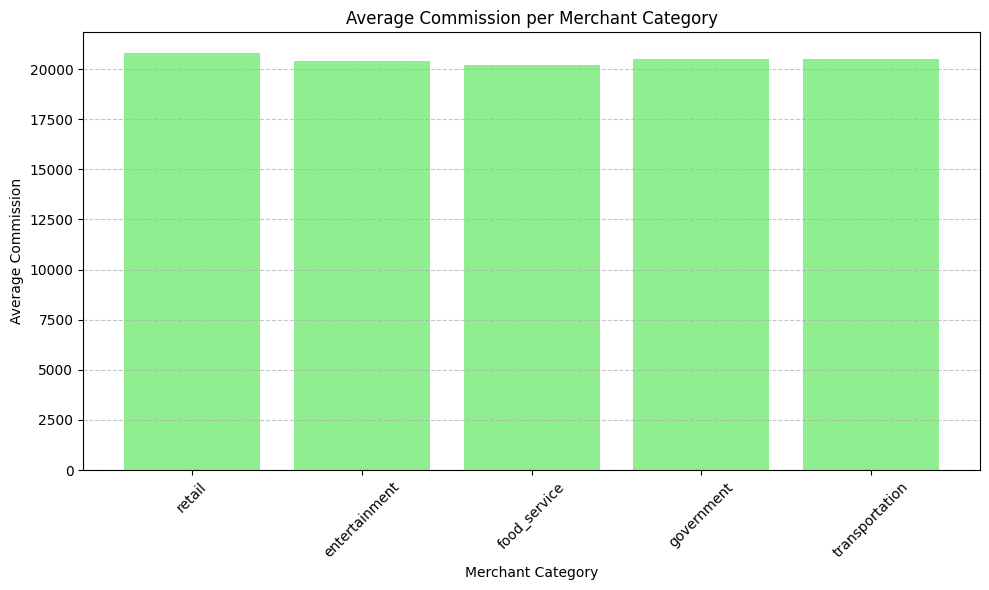

In [35]:
import matplotlib.pyplot as plt

average_commission_pd = average_commission.toPandas()

plt.figure(figsize=(10,6))
plt.bar(average_commission_pd['merchant_category'], average_commission_pd['average_commission'], color='lightgreen')
plt.xlabel('Merchant Category')
plt.ylabel('Average Commission')
plt.title('Average Commission per Merchant Category')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [36]:
average_commission_by_type = transactions_df.groupBy("merchant_category", "commission_type").agg(
	avg("commission_amount").alias("average_commission"),
)

average_commission_by_type.show()

+-----------------+---------------+------------------+
|merchant_category|commission_type|average_commission|
+-----------------+---------------+------------------+
|    entertainment|         tiered|20111.114330874603|
|   transportation|           flat|20522.104787234042|
|    entertainment|           flat|20665.974522292992|
|       government|         tiered| 20800.08494404883|
|           retail|         tiered|20844.492878942016|
|   transportation|         tiered|20572.840123775142|
|           retail|           flat|20583.665071770334|
|     food_service|           flat|19951.208847736627|
|           retail|    progressive|20949.684698608966|
|     food_service|    progressive|20360.971128608922|
|       government|           flat|19758.568546301085|
|    entertainment|    progressive| 20404.62749105774|
|       government|    progressive|20921.263186813187|
|   transportation|    progressive|20491.454353562007|
|     food_service|         tiered|20295.269645608627|
+---------

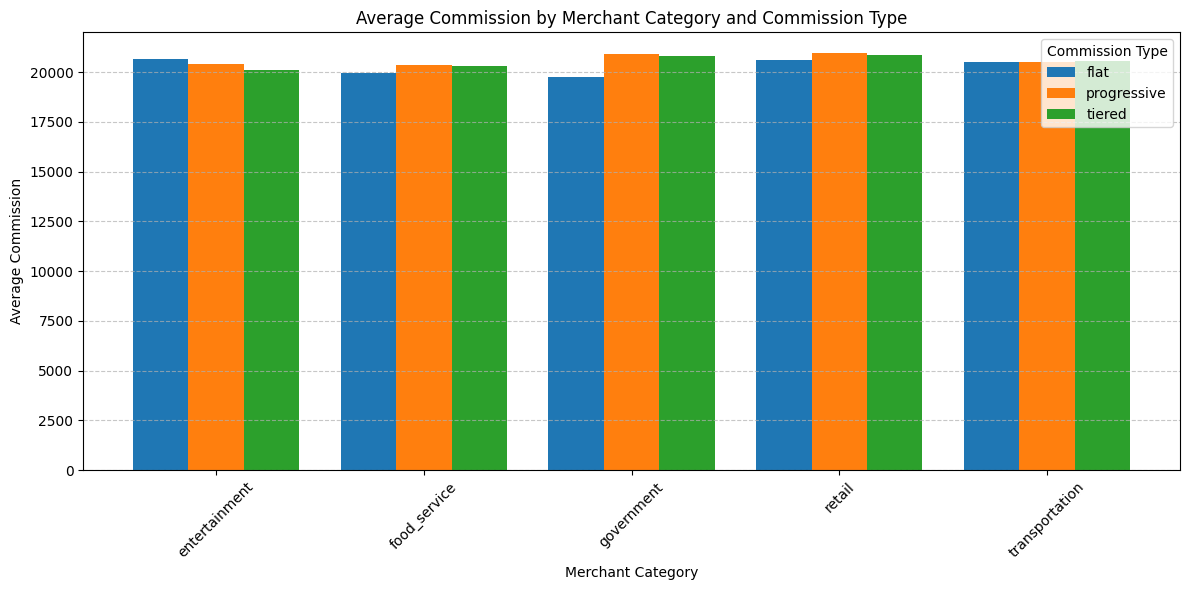

In [37]:
import matplotlib.pyplot as plt
import numpy as np

data = average_commission_by_type.collect()

categories = sorted(list(set(row['merchant_category'] for row in data)))
commission_types = sorted(list(set(row['commission_type'] for row in data)))

average_commissions = {ct: [] for ct in commission_types}

for cat in categories:
    for ct in commission_types:
        found = False
        for row in data:
            if row['merchant_category'] == cat and row['commission_type'] == ct:
                average_commissions[ct].append(row['average_commission'])
                found = True
                break
        if not found:
            average_commissions[ct].append(0) 
x = np.arange(len(categories)) 
width = 0.35 if len(commission_types) == 2 else 0.8 / len(commission_types)

fig, ax = plt.subplots(figsize=(12,6))

for idx, ct in enumerate(commission_types):
    ax.bar(x + idx * width, average_commissions[ct], width, label=ct)

ax.set_xlabel('Merchant Category')
ax.set_ylabel('Average Commission')
ax.set_title('Average Commission by Merchant Category and Commission Type')
ax.set_xticks(x + width * (len(commission_types) - 1) / 2)
ax.set_xticklabels(categories, rotation=45)
ax.legend(title='Commission Type')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


## Peak Transaction Times

In [38]:
from pyspark.sql.functions import hour
spark.conf.set("spark.sql.session.timeZone", "UTC")

transactions_by_hour = transactions_df.withColumn("hour", hour("timestamp")).groupBy("hour").count().orderBy("hour")
transactions_by_hour.show()

+----+-----+
|hour|count|
+----+-----+
|   0| 1178|
|   1| 1214|
|   2| 1208|
|   3| 1216|
|   4| 1226|
|   5| 1181|
|   6| 1232|
|   7| 1159|
|   8| 1241|
|   9| 1195|
|  10| 1128|
|  11| 1124|
|  12| 1183|
|  13| 1221|
|  14| 1251|
|  15| 1248|
|  16| 1191|
|  17| 1205|
|  18| 1178|
|  19| 1140|
+----+-----+
only showing top 20 rows



## Segmenting Customers Based On Spending Frequencies

In [39]:
from pyspark.sql.functions import when
from pyspark.sql.functions import max


customers_spending_frequencies = transactions_df.groupBy("customer_id") \
    .agg(count("*").alias("transaction_count"))

# customers_spending_frequencies.show()
# customers_spending_frequencies.select(max("transaction_count")).show()

segmented_customers = customers_spending_frequencies.withColumn(
    "customer_segment",
    when(col("transaction_count") < 2, "low_usage")
    .when((col("transaction_count") >= 2) & (col("transaction_count") <= 4), "medium_usage")
    .otherwise("high_usage")
)

segmented_customers.show()

+-----------+-----------------+----------------+
|customer_id|transaction_count|customer_segment|
+-----------+-----------------+----------------+
|   cust_655|               36|      high_usage|
|   cust_703|               28|      high_usage|
|   cust_399|               31|      high_usage|
|   cust_197|               31|      high_usage|
|   cust_582|               30|      high_usage|
|     cust_2|               35|      high_usage|
|   cust_478|               22|      high_usage|
|   cust_445|               29|      high_usage|
|   cust_246|               33|      high_usage|
|   cust_681|               23|      high_usage|
|   cust_349|               25|      high_usage|
|    cust_43|               34|      high_usage|
|   cust_942|               30|      high_usage|
|   cust_337|               17|      high_usage|
|   cust_653|               33|      high_usage|
|   cust_501|               27|      high_usage|
|   cust_924|               26|      high_usage|
|   cust_852|       

## Merchant Categories Separation

This one gives us some intuition about the patterns accross different categories of transactions. We can see which merchants have more volume and the difference between the count ofdifferent categories.

In [40]:
merchant_patterns = transactions_df.groupBy("merchant_category").agg(
    count("*").alias("transaction_count"),
    sum("amount").alias("total_amount"),
    avg("amount").alias("average_amount"),
    avg("commission_amount").alias("average_commission"), 
    (sum("commission_amount") / sum("amount")).alias("commission_ratio"), 
    avg("risk_level").alias("average_risk_level")
).orderBy("transaction_count", ascending=False)

merchant_patterns.show()

payment_method_by_category = transactions_df.groupBy("merchant_category", "payment_method") \
    .agg(count("*").alias("transaction_count")) \
    .orderBy("merchant_category", "transaction_count", ascending=[True, False])

payment_method_by_category.show()

+-----------------+-----------------+------------+------------------+------------------+--------------------+------------------+
|merchant_category|transaction_count|total_amount|    average_amount|average_commission|    commission_ratio|average_risk_level|
+-----------------+-----------------+------------+------------------+------------------+--------------------+------------------+
|     food_service|             5796|  5854528153|1010098.0250172532| 20201.46480331263|0.019999509258487633|2.0634920634920637|
|           retail|             5788|  6018215955|1039774.6985141672| 20795.00431928127|0.019999529079710466| 2.044402211472011|
|    entertainment|             5739|  5852013514|1019692.1962014288|20393.351977696464|0.019999517554087454|  2.03659174072138|
|       government|             5719|  5858289651|1024355.5955586641| 20486.61986361252|0.019999519651610342| 2.037419129218395|
|   transportation|             5714|  5865319086| 1026482.164158208| 20529.15645782289| 0.019999

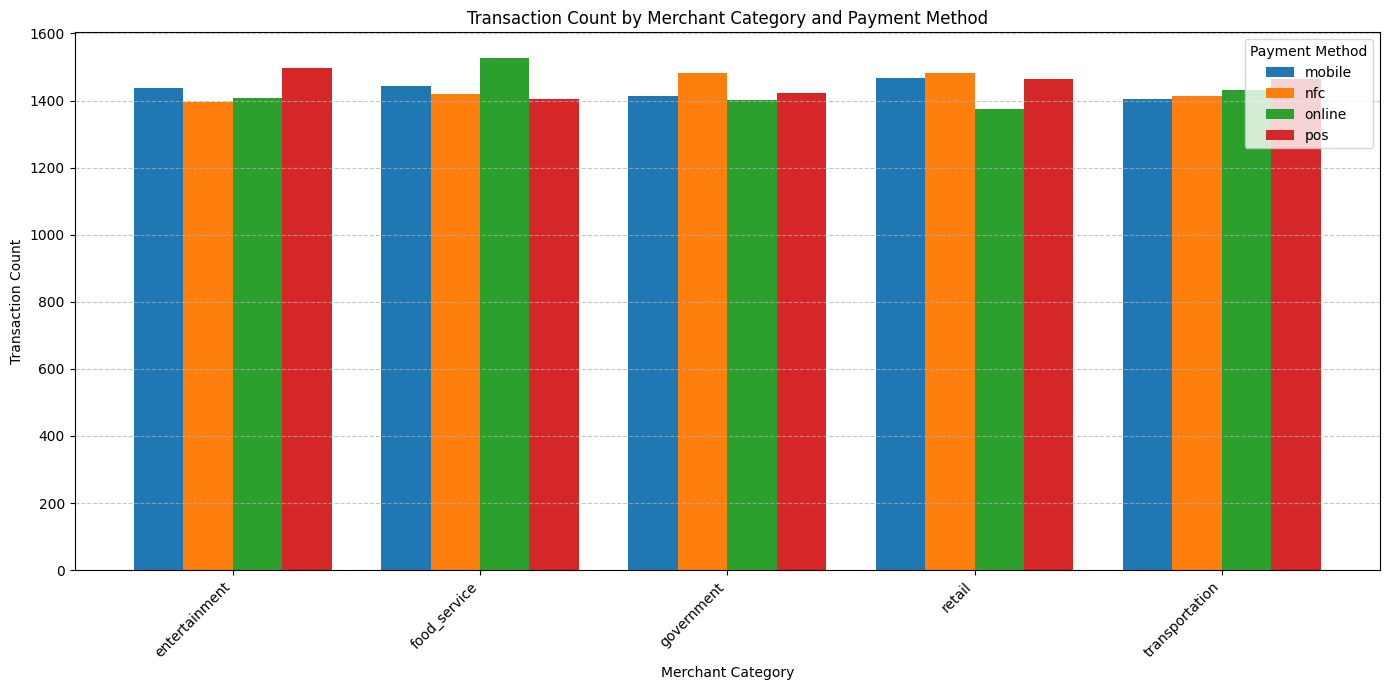

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

data = payment_method_by_category.collect()

categories = sorted(list(set(row['merchant_category'] for row in data)))
payment_methods = sorted(list(set(row['payment_method'] for row in data)))

transaction_counts = {pm: [] for pm in payment_methods}

for cat in categories:
    for pm in payment_methods:
        found = False
        for row in data:
            if row['merchant_category'] == cat and row['payment_method'] == pm:
                transaction_counts[pm].append(row['transaction_count'])
                found = True
                break
        if not found:
            transaction_counts[pm].append(0) 
x = np.arange(len(categories)) 
width = 0.8 / len(payment_methods)  

fig, ax = plt.subplots(figsize=(14,7))

for idx, pm in enumerate(payment_methods):
    ax.bar(x + idx * width, transaction_counts[pm], width, label=pm)

ax.set_xlabel('Merchant Category')
ax.set_ylabel('Transaction Count')
ax.set_title('Transaction Count by Merchant Category and Payment Method')
ax.set_xticks(x + width * (len(payment_methods) - 1) / 2)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.legend(title='Payment Method')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


## Day Meals Counts

In [42]:
transactions_with_part_of_day = transactions_df.withColumn("hour", hour("timestamp")) \
    .withColumn("part_of_day", 
        when((col("hour") >= 6) & (col("hour") < 12), "morning")
        .when((col("hour") >= 12) & (col("hour") < 16), "afternoon")
        .when((col("hour") >= 16) & (col("hour") < 21), "evening")
        .otherwise("night")
    )

transactions_by_part_of_day = transactions_with_part_of_day.groupBy("part_of_day") \
    .count() \
    .orderBy("part_of_day")

transactions_by_part_of_day.show()

+-----------+-----+
|part_of_day|count|
+-----------+-----+
|  afternoon| 4903|
|    evening| 5922|
|    morning| 7079|
|      night|10852|
+-----------+-----+



In [43]:
from pyspark.sql.functions import to_date

transactions_by_day = transactions_df.withColumn("date", to_date("timestamp")).groupBy("date").count().orderBy("date")

transactions_by_day.show()

+----------+-----+
|      date|count|
+----------+-----+
|2025-04-27| 8898|
|2025-04-28|19858|
+----------+-----+



In [ ]:
from pymongo import MongoClient
import pandas as pd

pandas_df = transactions_df.toPandas()
pandas_df["timestamp"] = pd.to_datetime(pandas_df["timestamp"])
records = []

for _, row in pandas_df.iterrows():
    record = row.to_dict()
    record["timestamp"] = record["timestamp"].to_pydatetime()
    records.append(record)

client = MongoClient("mongodb://localhost:27017/")
db = client["darooghe_db"]
collection = db["transactions"]
collection.delete_many({})
collection.insert_many(records)
collection.create_index("timestamp")
collection.create_index("merchant_category")
collection.create_index("customer_type")
print(collection.index_information())

ServerSelectionTimeoutError: localhost:27017: [Errno 111] Connection refused (configured timeouts: socketTimeoutMS: 20000.0ms, connectTimeoutMS: 20000.0ms), Timeout: 30s, Topology Description: <TopologyDescription id: 680fbf7fb0b6a9a0acbee18c, topology_type: Unknown, servers: [<ServerDescription ('localhost', 27017) server_type: Unknown, rtt: None, error=AutoReconnect('localhost:27017: [Errno 111] Connection refused (configured timeouts: socketTimeoutMS: 20000.0ms, connectTimeoutMS: 20000.0ms)')>]>

# Retention Policy


In [ ]:
from datetime import datetime, timedelta


cutoff_time = datetime.utcnow() - timedelta(minutes=1000)
result = collection.delete_many({"timestamp": {"$lt": cutoff_time}})
print(f"{result.deleted_count} documents removed.")
    
daily_summary = collection.aggregate([
    {
        "$group": {
            "_id": {
                "date": {"$dateToString": {"format": "%Y-%m-%d", "date": "$timestamp"}}
            },
            "total_transactions": {"$sum": 1},
            "total_amount": {"$sum": "$amount"}
        }
    },
    {"$sort": {"_id.date": 1}}
])  

merchant_daily_summary = collection.aggregate([
    {
        "$group": {
            "_id": {
                "merchant_category": "$merchant_category",
                "date": {"$dateToString": {"format": "%Y-%m-%d", "date": "$timestamp"}}
            },
            "total_transactions": {"$sum": 1},
            "total_amount": {"$sum": "$amount"}
        }
    },
    {"$sort": {"_id.date": 1}}
])

commission_by_category = collection.aggregate([
    {
        "$group": {
            "_id": {
                "category": "$merchant_category",
                "date": {"$dateToString": {"format": "%Y-%m-%d", "date": "$timestamp"}}
            },
            "total_commission": {"$sum": "$commission_amount"}
        }
    },
    {"$sort": {"_id.date": 1}}
])

db["daily_summary"].delete_many({})
db["daily_summary"].insert_many(list(daily_summary))
db["merchant_daily_summary"].delete_many({})
db["merchant_daily_summary"].insert_many(list(merchant_daily_summary))
db["commission_by_category"].delete_many({})
db["commission_by_category"].insert_many(list(commission_by_category))
for doc in db["daily_summary"].find().limit(5):
    print(doc)

0 documents removed.
{'_id': {'date': '2025-04-19'}, 'total_transactions': 909, 'total_amount': 933564008}
